# DDIM + Transformer

See README.md

In [1]:
# from google.colab import drive
# drive.mount('/content/drive/')
# %cd /content/drive/MyDrive/poselab/cern/ddim-transformer/

In [2]:
%pip install --upgrade pip -qqq
%pip install scipy plotly torch torchvision h5py numpy tqdm wandb -qqq

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import math
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path
import einops
import datetime
import sys
sys.path.append("../")
from utilities import *
import wandb


torch.cuda.empty_cache()

In [ ]:
CFG = dict(
    # --- data ---
    train_data_path = "../../calo-data/dataset_2_1.hdf5",
    test_data_path  = "../../calo-data/dataset_2_2.hdf5",
    showers_key = "showers",
    energies_key= "incident_energies",
    voxel_shape = (45, 16, 9),
    n_samples   = None,

    # --- model ---
    base_ch   = 16,
    ch_mults  = (1, 2, 4, 8),
    attn_res  = (2,),       # was (4, 2) — drops expensive 704-token level-1 attention
    cond_dim  = 128,
    compile   = False,      # set True on PyTorch 2+ for extra kernel-fusion speedup

    # --- diffusion ---
    T         = 1000,
    beta_min  = 1e-4,
    beta_max  = 0.02,
    schedule  = "cosine",

    # --- training ---
    epochs    = 200,
    batch_size= 64,         # was 16 — 4x fewer steps/epoch
    lr        = 1e-3,       # was 5e-4 — scaled linearly with batch (5e-4 * 64/16)
    grad_clip = 1.0,
    device    = "cuda" if torch.cuda.is_available() else "cpu",
    log_every = 10,

    # --- checkpointing ---
    ckpt_dir  = "checkpoints",
    save_every= 100,
    scratch   = 1,

    # --- wandb logging ---
    wandb_log    = 0,
    wandb_project= "ddim-t_voxel-cern2D",
    wandb_entity = "pgeorgantopoulos-ntua",
)

In [5]:
if CFG["wandb_log"]:
    wandb.init(
        entity=CFG["wandb_entity"],
        project=CFG["wandb_project"],
        config = CFG
    )

## Dataset

In [6]:
import sys
sys.path.append("../CaloChallenge/code")
from HighLevelFeatures import HighLevelFeatures

hlf = HighLevelFeatures('electron', filename='../CaloChallenge/code/binning_dataset_2.xml')
train_loader, test_loader, inverse = ddim_calochallenge_dataloaders(CFG, hlf)

Features in dataset_2_1.hdf5: ['incident_energies', 'showers']
Showers shape: (80000, 6480)
Incident energies shape: (80000, 1)
showers_4d shape: (80000, 9, 16, 45)
Features in dataset_2_1.hdf5: ['incident_energies', 'showers']
Showers shape: (20000, 6480)
Incident energies shape: (20000, 1)
showers_4d shape: (20000, 9, 16, 45)
Train: 80000 | Test: 20000


## Model

In [7]:
def sinusoidal_embedding(t: torch.Tensor, dim: int) -> torch.Tensor:
    """Sinusoidal time-step embedding (Vaswani et al.)."""
    half  = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
    )
    args = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)


class TimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
        self.net = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.SiLU(), nn.Linear(dim * 4, dim * 4),
        )

    def forward(self, t):
        return self.net(sinusoidal_embedding(t, self.dim))  # (B, dim*4)


# ── Building blocks ───────────────────────────────────────────────────────────

class ResBlock3D(nn.Module):
    """3-D residual block conditioned on a combined time+energy embedding."""

    def __init__(self, in_ch: int, out_ch: int, emb_dim: int):
        super().__init__()
        self.norm1    = nn.GroupNorm(8, in_ch)
        self.conv1    = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.norm2    = nn.GroupNorm(8, out_ch)
        self.conv2    = nn.Conv3d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch * 2)   # scale + shift (FiLM)
        self.skip     = nn.Conv3d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h              = self.conv1(F.silu(self.norm1(x)))
        scale, shift   = self.emb_proj(F.silu(emb)).chunk(2, dim=-1)
        h              = self.norm2(h) * (1 + scale[..., None, None, None]) \
                         + shift[..., None, None, None]
        return self.conv2(F.silu(h)) + self.skip(x)


class SelfAttn3D(nn.Module):
    """Multi-head self-attention over flattened spatial tokens."""

    def __init__(self, ch: int, heads: int = 4):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.attn = nn.MultiheadAttention(ch, heads, batch_first=True)

    def forward(self, x):
        B, C, D, H, W = x.shape
        h   = self.norm(x).reshape(B, C, -1).permute(0, 2, 1)   # (B, DHW, C)
        h, _ = self.attn(h, h, h)
        return x + h.permute(0, 2, 1).reshape(B, C, D, H, W)


# ── U-Net ─────────────────────────────────────────────────────────────────────

class UNet3D(nn.Module):
    """
    3-D U-Net denoiser for calorimeter showers.

    Args
        x_t  : (B, 1, D, H, W)  noisy shower at step t
        t    : (B,)              diffusion timestep indices  [0, T)
        cond : (B,)              log10(E_inc / GeV)

    Returns
        eps_pred : (B, 1, D, H, W)  predicted noise
    """

    def __init__(self, voxel_shape, base_ch=32, ch_mults=(1, 2, 4, 8),
                 attn_res=(4,), cond_dim=256):
        super().__init__()
        emb_dim  = base_ch * 4          # each half of the combined embedding
        full_emb = emb_dim * 2          # concat(t_emb, cond_emb)
        channels = [base_ch * m for m in ch_mults]
        n_levels = len(channels)

        self.time_emb  = TimeEmbedding(base_ch)
        self.cond_proj = nn.Sequential(
            nn.Linear(1, cond_dim), nn.SiLU(), nn.Linear(cond_dim, emb_dim)
        )

        def _res(i, o): return ResBlock3D(i, o, full_emb)
        def _attn(ch, lvl):
            res = min(voxel_shape) // (2 ** lvl)
            return SelfAttn3D(ch) if res in attn_res else nn.Identity()

        # Encoder
        self.in_conv = nn.Conv3d(1, channels[0], 3, padding=1)
        self.enc     = nn.ModuleList()
        self.downs   = nn.ModuleList()
        ch = channels[0]
        for i, out_ch in enumerate(channels):
            self.enc.append(nn.ModuleList([_res(ch, out_ch), _res(out_ch, out_ch), _attn(out_ch, i)]))
            self.downs.append(
                nn.Conv3d(out_ch, out_ch, 3, stride=2, padding=1) if i < n_levels - 1
                else nn.Identity()
            )
            ch = out_ch

        # Bottleneck — PatchEmbed3D + TransformerBlock replace SelfAttn3D here,
        # giving full-sequence attention with FiLM conditioning at coarsest resolution.
        mid = channels[-1]
        self.mid_r1          = _res(mid, mid)
        self.mid_r2          = _res(mid, mid)
        self.patch_embed_mid = PatchEmbed3D(mid, patch_size=(1, 1, 1), embed_dim=mid)
        self.trans_mid       = TransformerBlock(embed_dim=mid, num_heads=4, cond_embed_dim=full_emb)

        # Decoder (mirror encoder)
        self.dec   = nn.ModuleList()
        self.ups   = nn.ModuleList()
        skip_chs   = list(reversed(channels))
        for i in range(n_levels):
            skip_ch = skip_chs[i]
            out_ch  = skip_chs[i]
            up_ch   = channels[n_levels - 1 - max(0, i - 1)]
            self.ups.append(
                nn.ConvTranspose3d(channels[n_levels - 1 - (i - 1)],
                                   channels[n_levels - 1 - (i - 1)], 2, stride=2)
                if i > 0 else nn.Identity()
            )
            prev = channels[-1] if i == 0 else skip_chs[i - 1]
            self.dec.append(nn.ModuleList([
                _res(prev + skip_ch, out_ch), _res(out_ch, out_ch),
                _attn(out_ch, n_levels - 1 - i),
            ]))

        self.out_norm = nn.GroupNorm(8, channels[0])
        self.out_conv = nn.Conv3d(channels[0], 1, 1)

    def forward(self, x_t, t, cond):
        t_emb = self.time_emb(t)                        # (B, emb_dim)
        c_emb = self.cond_proj(cond.unsqueeze(-1))      # (B, emb_dim)
        emb   = torch.cat([t_emb, c_emb], dim=-1)       # (B, full_emb)

        h = self.in_conv(x_t)
        skips = []
        for (r1, r2, attn), ds in zip(self.enc, self.downs):
            h = r1(h, emb); h = r2(h, emb); h = attn(h)
            skips.append(h)
            h = ds(h)

        # Bottleneck: ResBlock → PatchEmbed3D → TransformerBlock → reshape → ResBlock
        h = self.mid_r1(h, emb)
        B_b, C_b, D_b, H_b, W_b = h.shape
        tokens = self.patch_embed_mid(h)                # (B, D_b*H_b*W_b, mid)
        tokens = self.trans_mid(tokens, emb)            # (B, D_b*H_b*W_b, mid)
        h = einops.rearrange(tokens, 'b (d h w) c -> b c d h w', d=D_b, h=H_b, w=W_b)
        h = self.mid_r2(h, emb)

        for (r1, r2, attn), us, skip in zip(self.dec, self.ups, reversed(skips)):
            h = us(h)
            h = F.interpolate(h, size=skip.shape[2:], mode="nearest")
            h = torch.cat([h, skip], dim=1)
            h = r1(h, emb); h = r2(h, emb); h = attn(h)

        return self.out_conv(F.silu(self.out_norm(h)))

class DDIMScheduler:
    """
    Noise scheduler for DDIM (Song et al., 2021 — arXiv:2010.02502).

    Training: identical to DDPM — samples a random t, adds noise, predicts ε.
    Sampling: deterministic (η=0) or stochastic (η>0) non-Markovian trajectory
              over a sub-sequence of T steps, allowing much fewer NFE.
    """

    def __init__(self, T: int = 1000, beta_min: float = 1e-4,
                 beta_max: float = 0.02, schedule: str = "cosine",
                 device: str = "cpu"):
        self.T      = T
        self.device = device

        if schedule == "linear":
            betas = torch.linspace(beta_min, beta_max, T, device=device)
        elif schedule == "cosine":
            # Nichol & Dhariwal (2021) cosine schedule
            steps = torch.arange(T + 1, device=device) / T
            f     = torch.cos((steps + 0.008) / 1.008 * math.pi / 2) ** 2
            betas = torch.clamp(1 - f[1:] / f[:-1], max=0.999)
        else:
            raise ValueError(f"Unknown schedule: {schedule}")

        alphas      = 1.0 - betas
        alpha_bar   = torch.cumprod(alphas, dim=0)

        self.register("betas",      betas)
        self.register("alphas",     alphas)
        self.register("alpha_bar",  alpha_bar)
        self.register("sqrt_ab",    alpha_bar.sqrt())
        self.register("sqrt_1mab",  (1 - alpha_bar).sqrt())

    def register(self, name, tensor):
        setattr(self, name, tensor)

    # ── Forward (training) ────────────────────────────────────────────────────

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor,
                 noise: torch.Tensor = None):
        """q(x_t | x_0) = sqrt(ā_t)*x_0 + sqrt(1-ā_t)*ε"""
        if noise is None:
            noise = torch.randn_like(x0)
        s  = self.sqrt_ab[t][:, None, None, None, None]
        s1 = self.sqrt_1mab[t][:, None, None, None, None]
        return s * x0 + s1 * noise, noise

    def training_loss(self, model, x0, cond):
        """Sample random t, corrupt x0, return MSE(ε_pred, ε)."""
        B    = x0.shape[0]
        t    = torch.randint(0, self.T, (B,), device=x0.device)
        x_t, noise = self.q_sample(x0, t)
        eps_pred   = model(x_t, t, cond)
        return F.mse_loss(eps_pred, noise)

    # ── Reverse (sampling) ────────────────────────────────────────────────────

    @torch.no_grad()
    def ddim_sample(self, model, shape, cond, steps: int = 50, eta: float = 0.0):
        """
        DDIM reverse process.

        Parameters
        ----------
        steps : number of denoising steps  (much less than T)
        eta   : 0 → fully deterministic;  1 → DDPM-equivalent stochasticity
        """
        device = self.device
        x = torch.randn(shape, device=device)

        # Sub-sequence τ evenly spaced in [0, T)
        tau = torch.linspace(self.T - 1, 0, steps + 1, device=device).long()

        for i in range(steps):
            t_cur  = tau[i]
            t_prev = tau[i + 1]
            t_vec  = t_cur.expand(shape[0])

            ab_t   = self.alpha_bar[t_cur]
            ab_prev= self.alpha_bar[t_prev] if t_prev >= 0 else torch.ones(1, device=device)

            eps    = model(x, t_vec, cond)
            x0_hat = (x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()
            x0_hat = x0_hat.clamp(-1, 1)

            sigma  = eta * ((1 - ab_prev) / (1 - ab_t) * (1 - ab_t / ab_prev)).sqrt()
            dir_xt = (1 - ab_prev - sigma ** 2).sqrt() * eps
            noise  = sigma * torch.randn_like(x) if eta > 0 else 0.0
            x      = ab_prev.sqrt() * x0_hat + dir_xt + noise

        return x


# Helper for Swin Transformer style patch merging
def _compute_dims(size, p_size):
    return [s // ps for s, ps in zip(size, p_size)]


class PatchEmbed3D(nn.Module):
    """
    3D Patch Embedding layer.
    Splits 3D input into patches, projects them to an embedding dimension,
    and flattens them into a sequence.
    """
    def __init__(self, in_channels: int, patch_size: tuple, embed_dim: int):
        super().__init__()
        self.patch_size = patch_size
        # Convolution to project patches to embed_dim
        # Stride = patch_size ensures non-overlapping patches
        self.proj = nn.Conv3d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (B, C, D, H, W)
        # Project patches
        x = self.proj(x)  # (B, embed_dim, D_p, H_p, W_p), where D_p, H_p, W_p are new dimensions

        # Flatten to sequence: (B, N, embed_dim), where N = D_p * H_p * W_p
        x = einops.rearrange(x, 'b c d h w -> b (d h w) c')
        return x

class TransformerBlock(nn.Module):
    """
    A basic Transformer Block with Multi-Head Self-Attention and an MLP.
    Supports conditioning via an embedding (e.g., time/energy).
    """
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: int = 4,
                 dropout_rate: float = 0.1, cond_embed_dim: int = None):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_hidden_dim, embed_dim),
            nn.Dropout(dropout_rate)
        )

        self.cond_proj = None
        if cond_embed_dim is not None:
            # FiLM-like conditioning on the MLP outputs or inputs
            self.cond_proj = nn.Linear(cond_embed_dim, embed_dim * 2)

    def forward(self, x: torch.Tensor, cond_emb: torch.Tensor = None) -> torch.Tensor:
        # x shape: (B, N, embed_dim)

        # Self-Attention
        identity = x
        x = self.norm1(x)
        x, _ = self.attn(x, x, x) # Query, Key, Value
        x = identity + x

        # MLP
        identity = x
        x = self.norm2(x)

        if self.cond_proj is not None and cond_emb is not None:
            scale, shift = self.cond_proj(F.silu(cond_emb)).chunk(2, dim=-1)
            # Apply conditioning (e.g., FiLM to MLP inputs or outputs)
            # Here, applying before MLP, similar to ResBlock3D
            x = x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

        x = self.mlp(x)
        x = identity + x
        return x

## Train

In [8]:
def train(cfg: dict, train_loader):
    device    = cfg["device"]
    ckpt_dir  = Path(cfg["ckpt_dir"])
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    model = UNet3D(
        voxel_shape = cfg["voxel_shape"],
        base_ch     = cfg["base_ch"],
        ch_mults    = cfg["ch_mults"],
        attn_res    = cfg["attn_res"],
        cond_dim    = cfg["cond_dim"],
    ).to(device)

    if cfg.get("compile", False):
        model = torch.compile(model)

    scheduler = DDIMScheduler(
        T        = cfg["T"],
        beta_min = cfg["beta_min"],
        beta_max = cfg["beta_max"],
        schedule = cfg["schedule"],
        device   = device,
    )

    n_params = sum(p.numel() for p in model.parameters())
    param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
    vram_gib = (param_bytes + buffer_bytes) / 1024**3
    print(f"  Parameters : {n_params / 1e6:.2f} M")
    print(f"  VRAM       : {vram_gib:.3f} GiB")

    opt    = AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    sched  = CosineAnnealingLR(opt, T_max=cfg["epochs"], eta_min=1e-6)
    scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

    start_epoch = 0
    loss_history = []

    if not cfg['scratch']:
        latest = sorted(ckpt_dir.glob("ckpt_epoch*.pt"))
        if latest:
            state = torch.load(latest[-1], map_location=device)
            model.load_state_dict(state["model"])
            opt.load_state_dict(state["opt"])
            sched.load_state_dict(state["sched"])
            if "scaler" in state:
                scaler.load_state_dict(state["scaler"])
            start_epoch = state["epoch"] + 1
            print(f"Resumed from {latest[-1]}  (epoch {start_epoch})")

    for epoch in range(start_epoch, cfg["epochs"]):
        model.train()
        epoch_loss = 0.0

        for x0, cond in train_loader:
            x0, cond = x0.to(device), cond.to(device)

            with torch.autocast("cuda", enabled=(device == "cuda")):
                loss = scheduler.training_loss(model, x0, cond)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            scaler.step(opt)
            scaler.update()
            opt.zero_grad()

            epoch_loss += loss.item()

        sched.step()
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)

        if (epoch + 1) % cfg['log_every'] == 0:
            print(f"Epoch {epoch+1:4d}/{cfg['epochs']}  |  loss={avg_loss:.5f}"
                  f"  lr={sched.get_last_lr()[0]:.2e}")
            if wandb.run is not None:
                wandb.log({"train_loss": avg_loss, "learning_rate": sched.get_last_lr()[0]}, step=epoch + 1)

        if (epoch + 1) % cfg["save_every"] == 0:
            ckpt_path = ckpt_dir / f"ckpt{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M')}_epoch{epoch+1:04d}.pt"
            torch.save({
                "epoch":  epoch,
                "model":  model.state_dict(),
                "opt":    opt.state_dict(),
                "sched":  sched.state_dict(),
                "scaler": scaler.state_dict(),
                "cfg":    cfg,
            }, ckpt_path)
            print(f"  -> saved {ckpt_path}")

    return model, scheduler, loss_history


print("device:", CFG["device"])

device: cuda


In [9]:
# model, scheduler, loss_history_initial = train(CFG, train_loader)

# fig = plt.figure(figsize=(10, 6))
# plt.plot(loss_history_initial)
# plt.title('Training Loss Over Epochs (Initial Run)')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.grid(True)
# if wandb.run is not None:
#     wandb.log({"loss_curve": wandb.Image(fig)})
# plt.show()

## Load pretrained model

In [10]:
model, scheduler = load_model_from_checkpoint(CFG, UNet3D, DDIMScheduler)

Loading checkpoints/ckpt2026-06-26_20-04_epoch0200.pt  (epoch 200)
{'data_path': '../../calo-data/dataset_2_1.hdf5', 'showers_key': 'showers', 'energies_key': 'incident_energies', 'voxel_shape': (45, 16, 9), 'n_samples': None, 'base_ch': 16, 'ch_mults': (1, 2, 4, 8), 'attn_res': (2,), 'cond_dim': 128, 'compile': False, 'T': 1000, 'beta_min': 0.0001, 'beta_max': 0.02, 'schedule': 'cosine', 'epochs': 200, 'batch_size': 64, 'lr': 0.001, 'grad_clip': 1.0, 'device': 'cuda', 'log_every': 10, 'ckpt_dir': 'checkpoints', 'save_every': 100, 'scratch': 1, 'wandb_log': 1, 'wandb_project': 'ddim_transformers-cern2D', 'wandb_entity': 'pgeorgantopoulos-ntua'}
  Parameters : 7.91 M  |  VRAM : 0.029 GiB
Model loaded from epoch 200.


## Eval

### (E_INC= [1, 10, 100, 1000, 2000], PID, GEOMETRY)

In [11]:
ENERGIES_GEV = [1, 10, 100, 1000, 2000]
N_SWEEP      = 100

with h5py.File(CFG["test_data_path"], "r") as f:
    _all_E       = f[CFG["energies_key"]][:].flatten()   # MeV
    _all_showers = f[CFG["showers_key"]][:]

E_INC_MIN = _all_E.min()
E_INC_MAX = _all_E.max()

sweep = {}
for e_gev in ENERGIES_GEV:
    gen = generate(model, scheduler, CFG, inverse=inverse,
                   n_samples=N_SWEEP, e_inc_gev=e_gev).squeeze(1)  # (N, 45, 16, 9)

    E_mev = e_gev * 1e3
    mask  = (_all_E > E_mev / 2) & (_all_E < E_mev * 2)
    gt    = _all_showers[mask][:N_SWEEP].reshape(-1, *CFG["voxel_shape"])

    sweep[e_gev] = {"gen": gen, "gt": gt}
    if mask.any():
        print(f"E = {e_gev:>5} GeV | gen {gen.shape[0]:>3} | gt {gt.shape[0]:>3}"
            f" | GT range {_all_E[mask].min()/1e3:.2f}–{_all_E[mask].max()/1e3:.2f} GeV")
    else:
        print(f"E = {e_gev:>5} GeV | gen {gen.shape[0]:>3}")

E =     1 GeV | gen 100 | gt 100 | GT range 1.00–2.00 GeV
E =    10 GeV | gen 100 | gt 100 | GT range 5.00–20.00 GeV
E =   100 GeV | gen 100 | gt 100 | GT range 50.02–200.00 GeV
E =  1000 GeV | gen 100 | gt 100 | GT range 500.06–999.93 GeV
E =  2000 GeV | gen 100


### Z-profiles

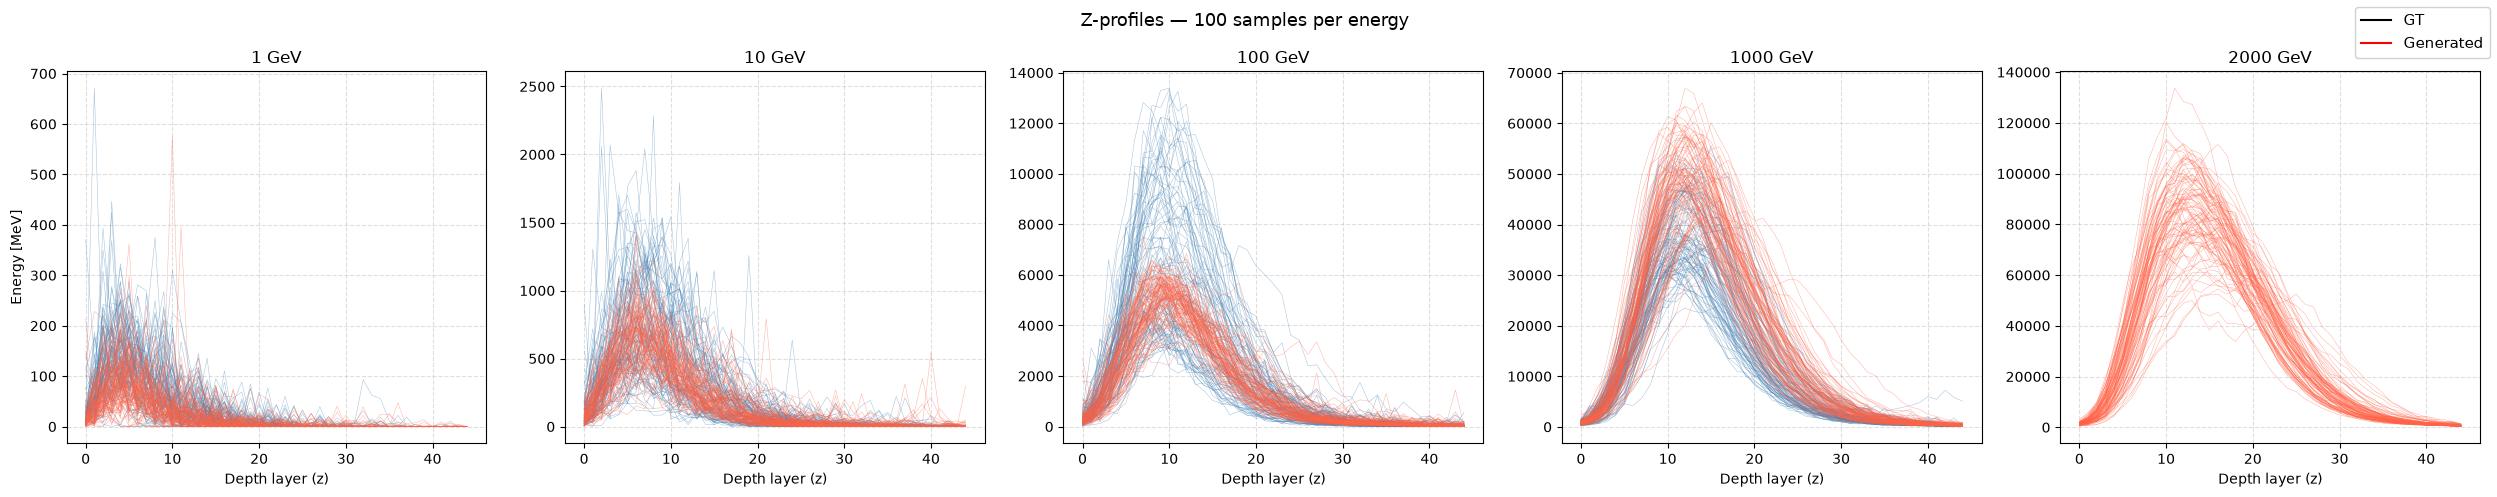

In [12]:
n_e  = len(ENERGIES_GEV)
fig, axes = plt.subplots(1, n_e, figsize=(5 * n_e, 5), sharey=False)

for ax, e_gev in zip(axes, ENERGIES_GEV):
    gt_z  = sweep[e_gev]["gt"].sum(axis=(2, 3))   # (N, 45) — sum over phi × r
    gen_z = sweep[e_gev]["gen"].sum(axis=(2, 3))

    ax.plot(gt_z.T,  lw=0.35, color="steelblue", alpha=0.5)
    ax.plot(gen_z.T, lw=0.35, color="tomato",    alpha=0.5)
    ax.set_title(f"{e_gev} GeV", fontsize=12)
    ax.set_xlabel("Depth layer (z)")
    ax.grid(linestyle="--", alpha=0.4)
    if ax is axes[0]:
        ax.set_ylabel("Energy [MeV]")

legend_handles = [
    plt.Line2D([], [], color="black", lw=1.5, label="GT"),
    plt.Line2D([], [], color="red",    lw=1.5, label="Generated"),
]
fig.legend(handles=legend_handles, loc="upper right", fontsize=11, framealpha=0.9)
fig.suptitle(f"Z-profiles — {N_SWEEP} samples per energy", fontsize=13)
fig.tight_layout()
if wandb.run is not None:
    wandb.log({"sweep/z_profiles": wandb.Image(fig)})
plt.show()

### Energy Distribution + Radial Profile Comparison

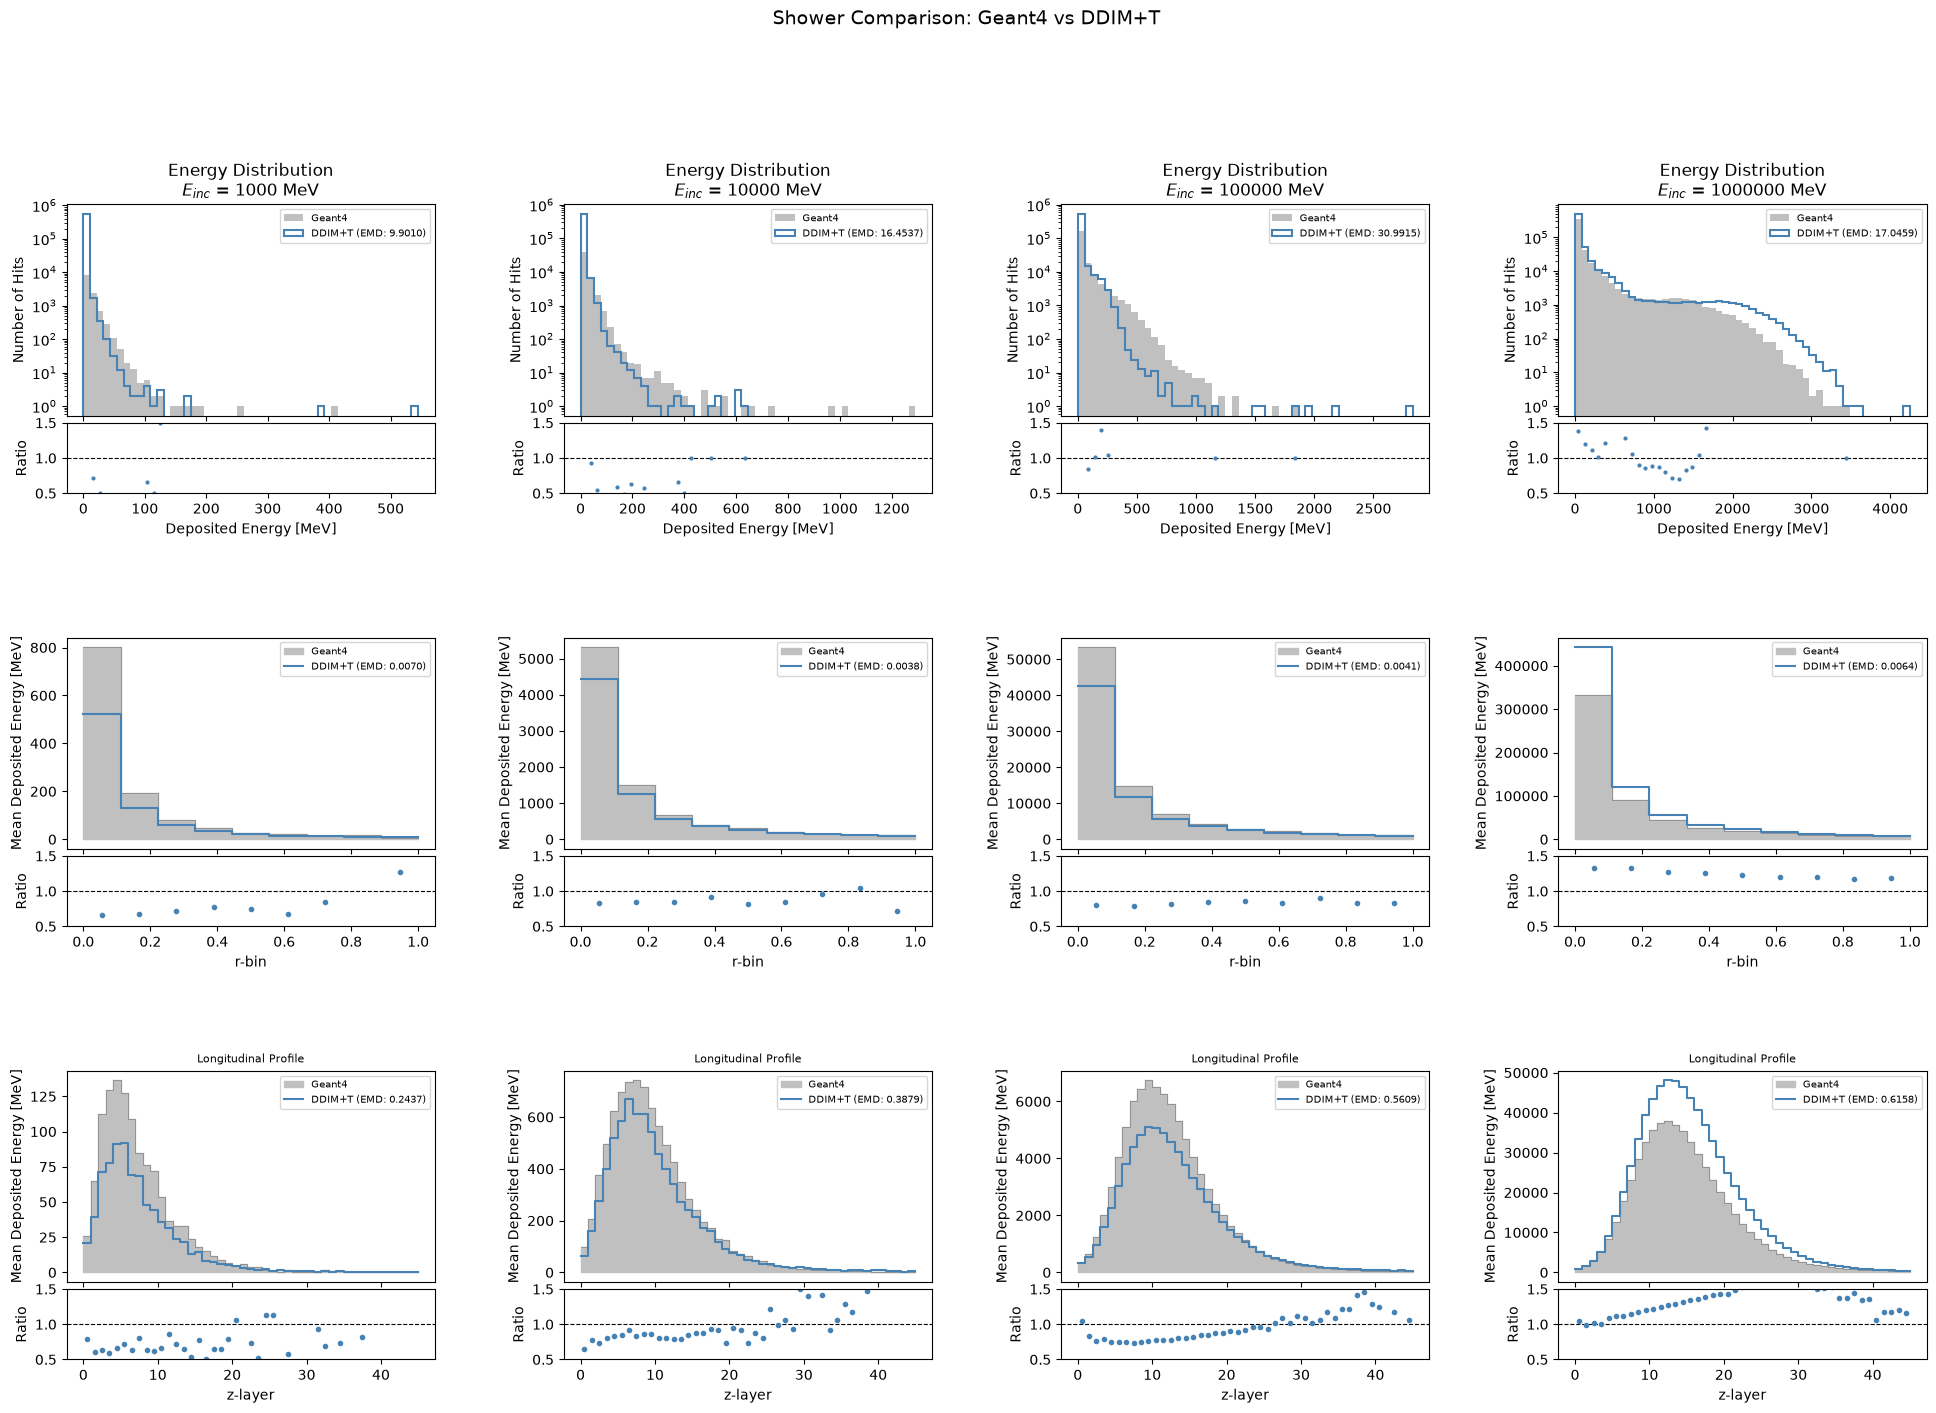

In [13]:
# plot_comparison expects (K, R, PHI, Z); sweep data is (N, Z, PHI, R) — transpose needed
def to_rphiz(arr):
    return arr.transpose(0, 3, 2, 1)  # (N, Z, PHI, R) → (N, R, PHI, Z)

# Only include energy levels that have GT data
available_e = [e for e in ENERGIES_GEV if sweep[e]["gt"].shape[0] > 0]

ref_showers_all  = np.concatenate([to_rphiz(sweep[e]["gt"])  for e in available_e], axis=0)
gen_showers_all  = np.concatenate([to_rphiz(sweep[e]["gen"]) for e in available_e], axis=0)
ref_energies_all = np.concatenate([np.full(sweep[e]["gt"].shape[0],  e * 1e3) for e in available_e])
gen_energies_all = np.concatenate([np.full(sweep[e]["gen"].shape[0], e * 1e3) for e in available_e])

fig = plot_comparison(ref_showers_all, ref_energies_all,
                      gen_showers_all, gen_energies_all,
                      gen_label="DDIM+T", n_cols=len(available_e))
if wandb.run is not None:
    wandb.log({"comparison": wandb.Image(fig)})
plt.show()